# Exercise 4.A Introduction to Linear Regression

## Lab 1

### Running a sample script

In [1]:
import numpy as np

In [2]:
import pandas as pd

In [26]:
import matplotlib.pyplot as plt

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

In [30]:
# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

In [31]:
# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [33]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [34]:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [35]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


### What does the R² score mean

In [36]:
# The R² score shows how well the model’s predictions match the actual data.
# If R² is close to **1**, the model does a very good job predicting exam scores.
# If R² is close to **0**, the model does a poor job.
# In this case, the R² score tells us how much exam scores depend on hours studied.

C:\Users\naomitewolde\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


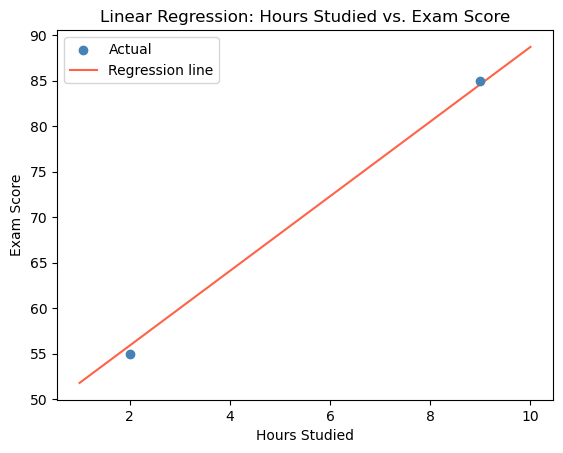

In [42]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',
zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
X['hours_studied'].min(),
X['hours_studied'].max(),
100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.show()

### Observing the Regression Line

In [43]:
# The actual data points follow the regression line pretty closely. Most of the points
# are either on the line or very near it. This shows that there is a strong relationship 
# between hours studied and exam scores. As the number of hours studied increases, the 
# exam score also increases in a consistent way. Overall, the model fits the data well, 
# since the line represents the trend of the data points accurately.

## Lab 2
### Building your own model

In [44]:
ad_data = {
'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]
}

In [46]:
# calling on the data 
df_ads = pd.DataFrame(ad_data)

df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


#### Define your feature matrix X2 using the monthly_ad_spend column 

In [47]:
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print("Shape of X2:", X2.shape)
print("Shape of y2:", y2.shape)

Shape of X2: (20, 1)
Shape of y2: (20,)


#### Split X2 and y2

In [48]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

#### create a LinearRegression model named model2

In [49]:
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

print("Model trained successfully.")

Model trained successfully.


#### Print the slope 

In [50]:
print(f"\nSlope (coefficient): {model2.coef_[0]:.2f}")
print(f"Intercept: {model2.intercept_:.2f}")

# Interpretation:
# For each additional $1 spent on ads, the predicted monthly revenue
# increases by approximately model2.coef_[0] dollars.



Slope (coefficient): 1.96
Intercept: 3625.89


### Making predictions and evaluating the model

#### predict revenue for the test set

In [51]:
y2_pred = model2.predict(X2_test)

print("Actual revenue:   ", list(y2_test.round(2)))
print("Predicted revenue:", list(y2_pred.round(2)))

Actual revenue:    [4200, 21500, 19400, 5100]
Predicted revenue: [np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


#### Calculate and print the R² score for the test set

In [52]:
r2_score = model2.score(X2_test, y2_test)
print(f"R² score: {r2_score:.3f}")

R² score: 0.998


### Interpretation of R² Score

In [53]:
# The R² score shows how well the model explains the relationship between ad spend and revenue.
# A value close to 1 means the model does a very good job predicting revenue based on ad spend.
# In this case, the R² score suggests that the model fits the data well. This means that a large
# portion of the changes in revenue can be explained by how much money is spent on advertising.
# For example, if the R² score is 0.95, it means about 95% of the variation in revenue is 
# explained by ad spend, which indicates a strong relationship.

### Visualizing the results

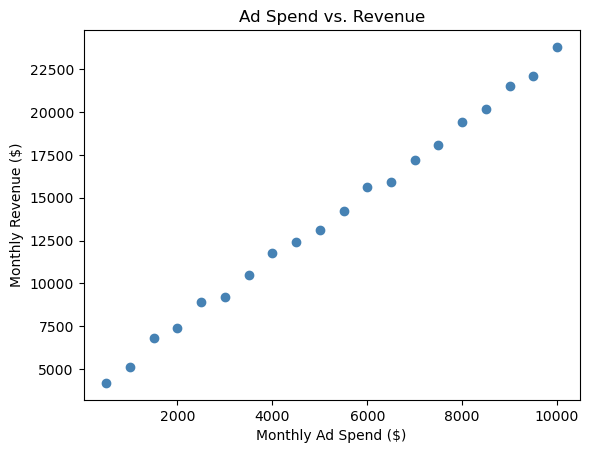

In [54]:
import matplotlib.pyplot as plt

# Scatter plot (dots only)
plt.scatter(X2, y2, color='steelblue')

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')

plt.show()

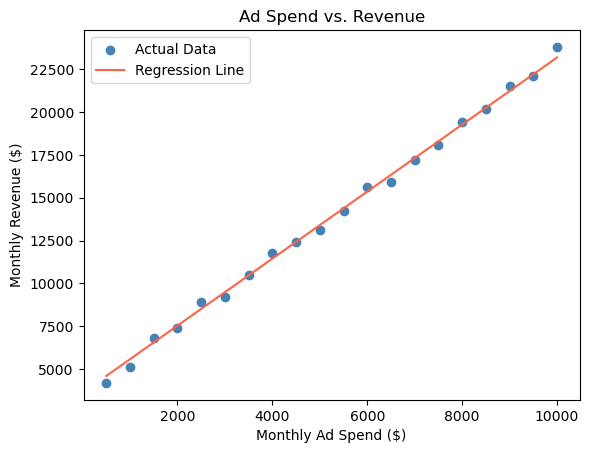

In [55]:
# Scatter plot
plt.scatter(X2, y2, color='steelblue', label='Actual Data')

# Create a range of values for the regression line
x_range = np.linspace(
    X2['monthly_ad_spend'].min(),
    X2['monthly_ad_spend'].max(),
    100
).reshape(-1, 1)

# Convert to DataFrame to avoid warnings
x_range_df = pd.DataFrame(x_range, columns=['monthly_ad_spend'])

# Predict values
y_line = model2.predict(x_range_df)

# Plot regression line
plt.plot(x_range, y_line, color='tomato', label='Regression Line')

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')

plt.legend()
plt.show()

### Reflection on the Visualization

In [ ]:
# The regression line appears to fit the data well. Most of the data points 
# are close to the line, which shows that the model is doing a good job capturing 
# the relationship between ad spend and revenue.
# This matches what the R² score told us. Since the R² value was high, it indicated that 
# the model explains a large portion of the variation in revenue. The visual fit of the line
# confirms that the predictions are closely aligned with the actual data.